# **Sentiment Analysis**
This notebook serves as the starting point for a project aimed at comparing the effectiveness of selected Natural Language Processing models in sentiment analysis.

## **Project Scope**

Sentiment analysis is an NLP task that involves identifying and classifying emotions or opinions expressed in text. In this study, I aim to evaluate the performance of the following models:

- Support Vector Machines (SVM)
- Convolutional Neural Networks (CNN)
- Long Short-Term Memory Networks (LSTM)
- Bidirectional Encoder Representations from Transformers (BERT)

The analysis will be conducted using datasets - Sentiment140, Amazon Books Reviews and Yelp Reviews.

### **Notebook Sections**

#### **1. Data Loading**  
Loads datasets from CSV files (Amazon Books Reviews, Sentiment140, Yelp Reviews) and extracts relevant columns for sentiment analysis.

#### **2. Exploratory Data Analysis (EDA)**  
Performs an initial inspection of the datasets, including dataset previews and a bar chart visualizing record counts.

#### **3. Data Preprocessing**  
Standardizes sentiment labels across datasets to ensure consistency in model training.  
- **3.1 Amazon Books Reviews:** Cleans data and unifies polarity labels.  
- **3.2 Sentiment140:** Prepares the dataset by formatting labels and text.  
- **3.3 Yelp Reviews:** Processes review texts and ensures compatibility with other datasets.  

#### **4. Sampling and Saving Data**  
Creates smaller samples of datasets for testing and saves preprocessed versions for further analysis.  

# 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils

In [3]:
# load datasets
amazon_file = '../data/raw/amazon_books_ratings.csv'
sentiment140_file = '../data/raw/sentiment140.csv'
yelp_file = '../data/raw/yelp_reviews.csv'

# read datasets
amazon_df = pd.read_csv(amazon_file, engine='python', names=["Polarity", "Review"], skiprows=1, usecols=[6, 8], encoding="ISO-8859-1")
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', names=["Polarity", "Review"], usecols=[0, 5], encoding="ISO-8859-1")
yelp_df = pd.read_csv(yelp_file, engine='python', names=["Polarity", "Review"], encoding="ISO-8859-1")

In [4]:
# inspect dataframes
print("Amazon Books Reviews DataFrame:")
print(amazon_df.head())
print("\nSentiment140 DataFrame:")
print(sentiment140_df.head())
print("\nYelp Reviews DataFrame:")
print(yelp_df.head())

Amazon Books Reviews DataFrame:
   Polarity                                           Review
0       4.0           Nice collection of Julie Strain images
1       5.0                                Really Enjoyed It
2       5.0  Essential for every personal and Public Library
3       4.0  Phlip Nel gives silly Seuss a serious treatment
4       4.0                           Good academic overview

Sentiment140 DataFrame:
   Polarity                                             Review
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....

Yelp Reviews DataFrame:
   Polarity                                             Review
0         1  Unfortunately, the frustration of being Dr. Go...
1         2  Been going to Dr. Goldberg for over

# 2. Exploratory Data Analysis

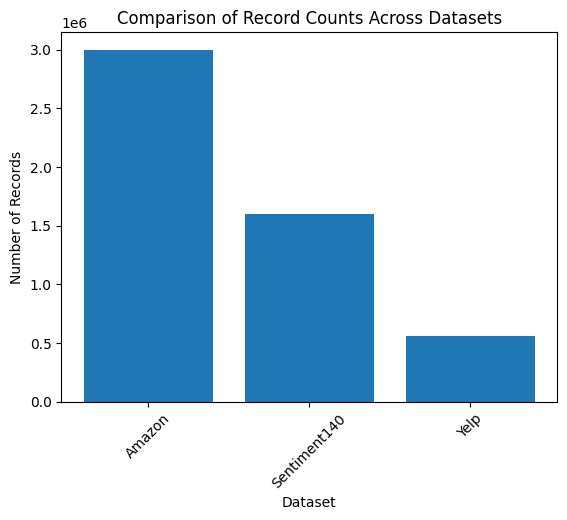

In [5]:
# plot chart showing the number of records per dataset
data = {'Dataset': ['Amazon', 'Sentiment140', 'Yelp'], 'Number of Records': [len(amazon_df), len(sentiment140_df), len(yelp_df)]}

df = pd.DataFrame(data)

plt.bar(df['Dataset'], df['Number of Records'])
plt.xlabel('Dataset') 
plt.ylabel('Number of Records')
plt.title('Comparison of Record Counts Across Datasets')
plt.xticks(rotation=45) 
plt.show()

In [6]:
# list of dataframes and their names
dfs = [amazon_df, sentiment140_df, yelp_df]
dataset_names = ['Amazon', 'Sentiment140', 'Yelp']

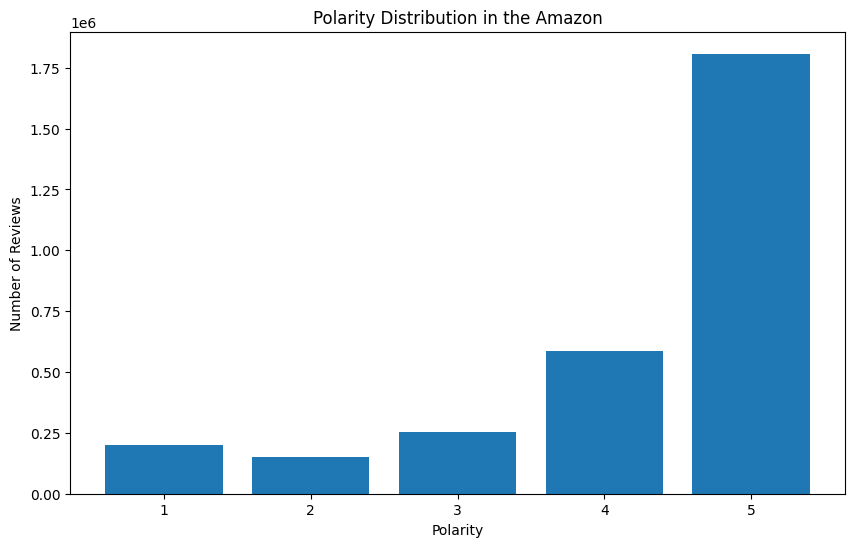

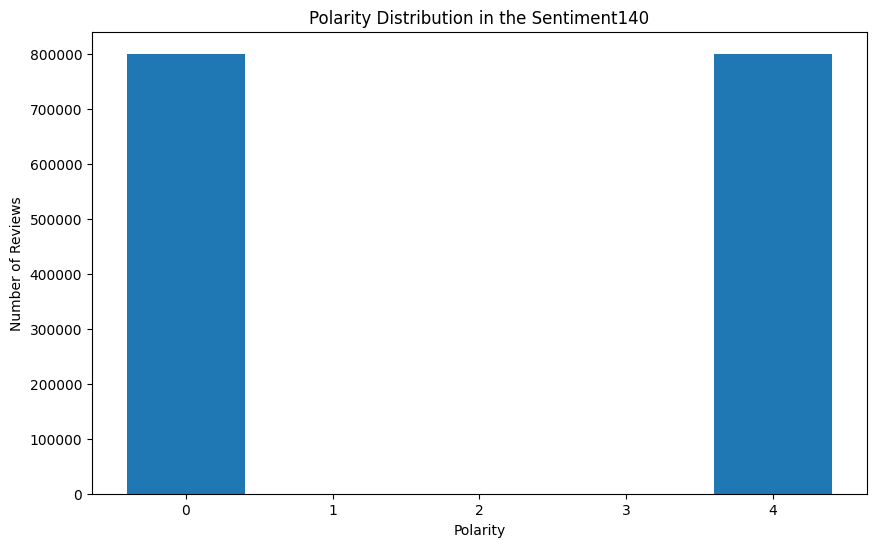

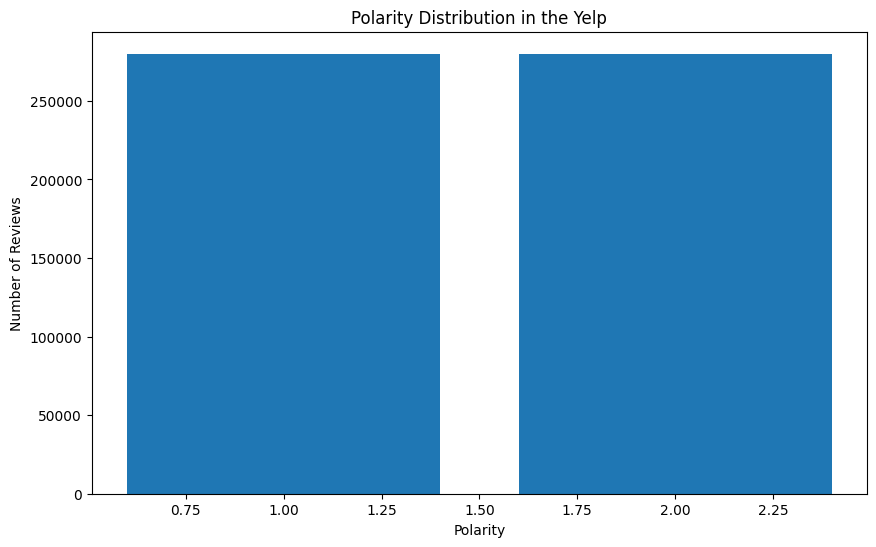

In [7]:
# plot distribution of review polarity across datasets
for df, name in zip(dfs, dataset_names):
    DataUtils.plot_polarity_distribution(df, name)

In [8]:
import nltk

# download the tokenizer for sentence and word tokenization
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

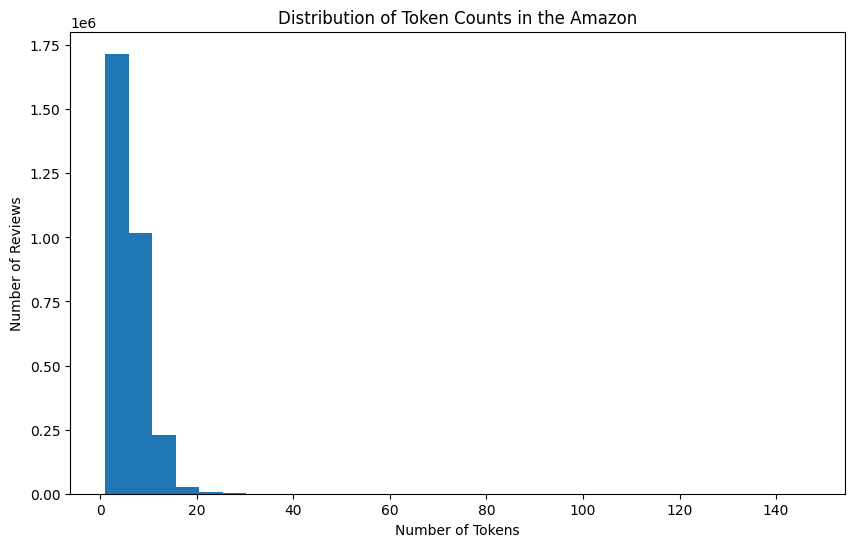

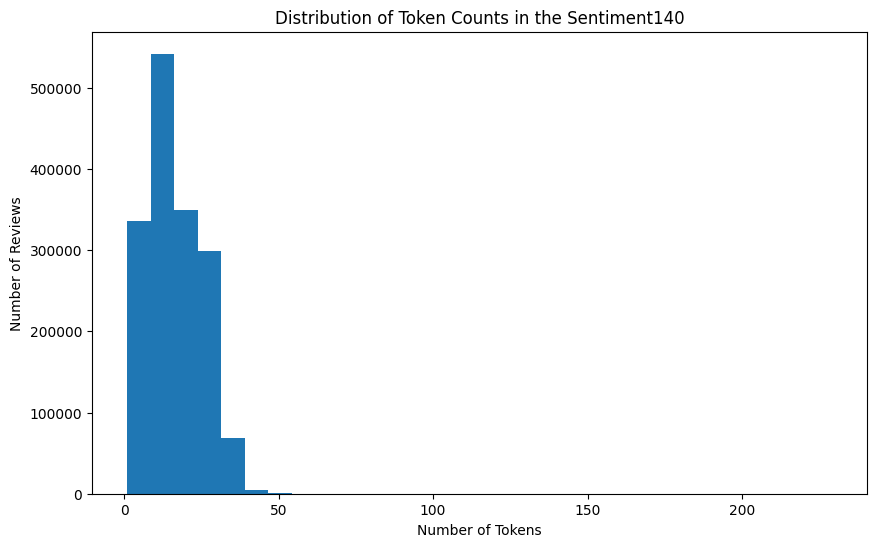

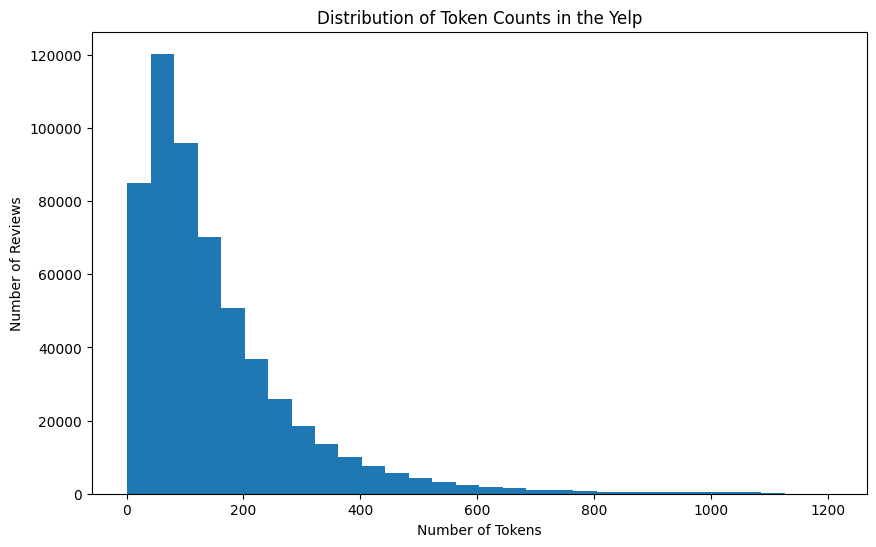

In [9]:
# plot the distribution of token counts across datasets by polarity
for df, name in zip(dfs, dataset_names):
    DataUtils.plot_token_distribution(df, name)

# 3. Data Initial Preprocessing - unifying 'Polarity' labels

## 3.1 Data Preprocessing - Amazon Books Ratings

In [10]:
# standardize the dataset
# count the number of records for each class
count_1 = len(amazon_df[amazon_df['Polarity'] == 1.0])
count_2 = len(amazon_df[amazon_df['Polarity'] == 2.0])
count_4 = len(amazon_df[amazon_df['Polarity'] == 4.0])
count_5 = len(amazon_df[amazon_df['Polarity'] == 5.0])

count_1_and_2 = count_1 + count_2

# calculate the number of records to keep for class 5.0
factor_5 = count_5 / (count_5 + count_4)
num_records_5 = int(round(factor_5 * count_1_and_2))

# calculate the number of records to keep for class 4.0
num_records_4 = (count_1 + count_2) - num_records_5

# select records from class 5.0
class_5_sampled = amazon_df[amazon_df['Polarity'] == 5.0].sample(n=num_records_5, random_state=42)

# select records from class 4.0
class_4_sampled = amazon_df[amazon_df['Polarity'] == 4.0].sample(n=num_records_4, random_state=42)

# select all records from classes 1.0 and 2.0
class_1_all = amazon_df[amazon_df['Polarity'] == 1.0]
class_2_all = amazon_df[amazon_df['Polarity'] == 2.0]

# remove records with class 3.0
amazon_df = amazon_df[amazon_df['Polarity'] != 3.0]

# combine the selected records into a single DataFrame
amazon_balanced_df = pd.concat([class_5_sampled, class_4_sampled, class_1_all, class_2_all])

# reset the index in the final DataFrame
amazon_balanced_df.reset_index(drop=True, inplace=True)

# display a summary of the polarity distribution
print(amazon_balanced_df['Polarity'].value_counts())


Polarity
5.0    266420
1.0    201688
2.0    151058
4.0     86326
Name: count, dtype: int64


In [11]:
# unify numerical polarity value
amazon_balanced_df['Polarity'] = amazon_balanced_df['Polarity'].replace({
    1.0: 0,
    2.0: 0,
    4.0: 1,
    5.0: 1
}).astype(int)

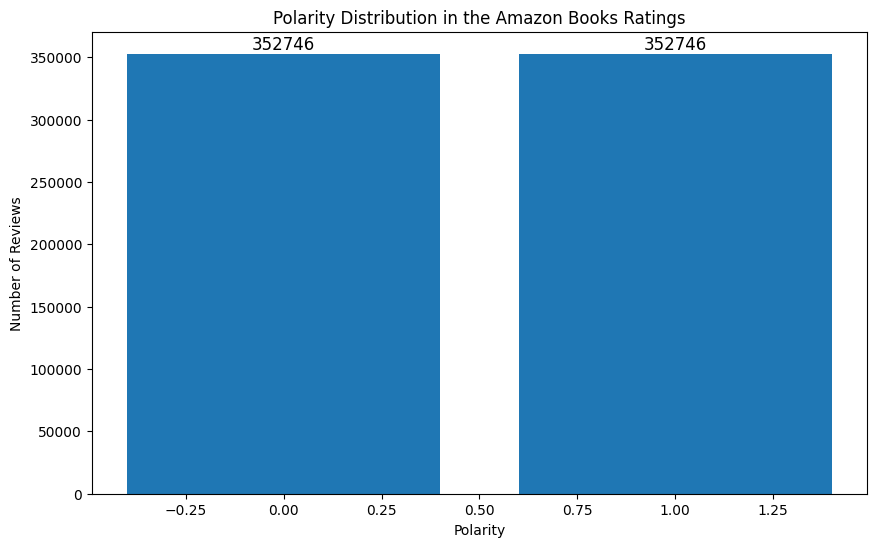

In [12]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(amazon_balanced_df, 'Amazon Books Ratings')

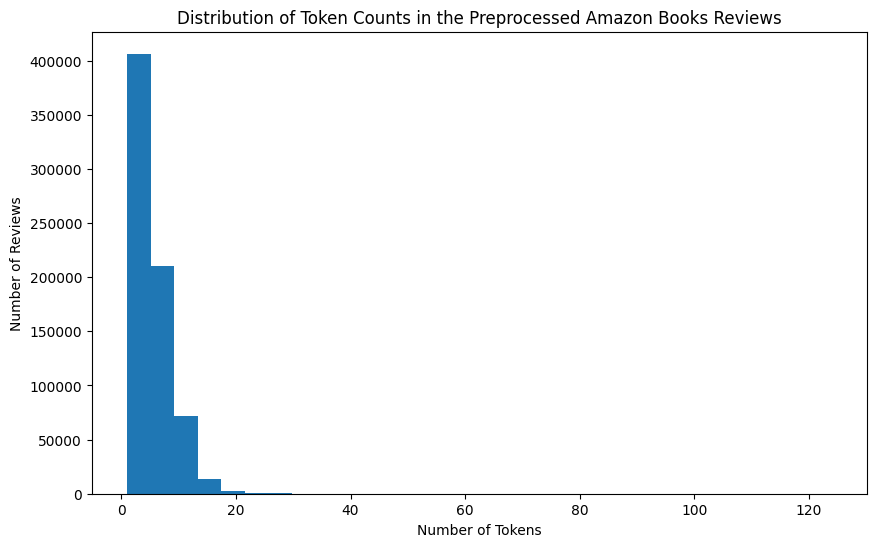

In [13]:
# plot the distribution of token counts
DataUtils.plot_token_distribution(amazon_balanced_df, 'Preprocessed Amazon Books Reviews')

In [14]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(amazon_balanced_df, 'Review')

    Token   Count
0       !  151674
1     the   89732
2       ,   86095
3      of   80021
4       .   72914
5    book   70620
6       A   65915
7       a   64552
8     and   56237
9      to   45803
10    The   41887
11      I   41212
12    for   41086
13      ?   34016
14     is   33011
15    ...   31506
16     's   30342
17   this   29688
18     it   28007
19   read   25614
20    Not   24563
21  Great   24096
22     in   24006
23    n't   22904
24   Book   21991


## 3.2 Data Preprocessing - Sentiment140

In [15]:
# unify numerical polarity value
sentiment140_df['Polarity'] = sentiment140_df['Polarity'].replace({0: 0, 4: 1})

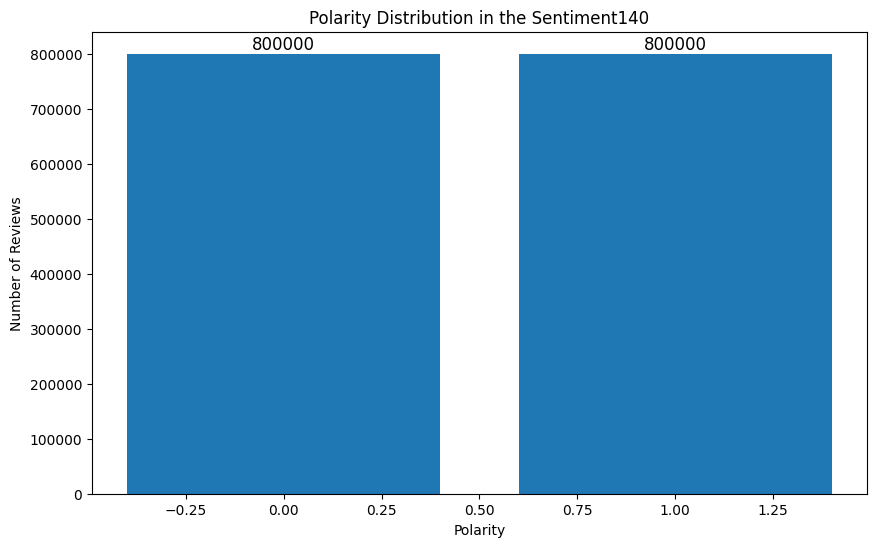

In [16]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(sentiment140_df, 'Sentiment140')

In [17]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(sentiment140_df, 'Review')  

   Token   Count
0      !  917950
1      .  804773
2      @  798682
3      I  652879
4     to  557549
5    the  490130
6      ,  484468
7      a  367729
8      i  299245
9     my  282842
10   and  281822
11   you  268826
12    it  260944
13     ?  247562
14    is  230283
15   ...  220073
16   for  211842
17    in  207194
18    of  180533
19    's  179216
20   n't  173581
21     ;  166822
22    on  160301
23    me  154979
24  that  147660


## 3.3 Data Preprocessing - Yelp Reviews

In [18]:
# unify numerical polarity value
yelp_df['Polarity'] = yelp_df['Polarity'].replace({1: 0, 2: 1})

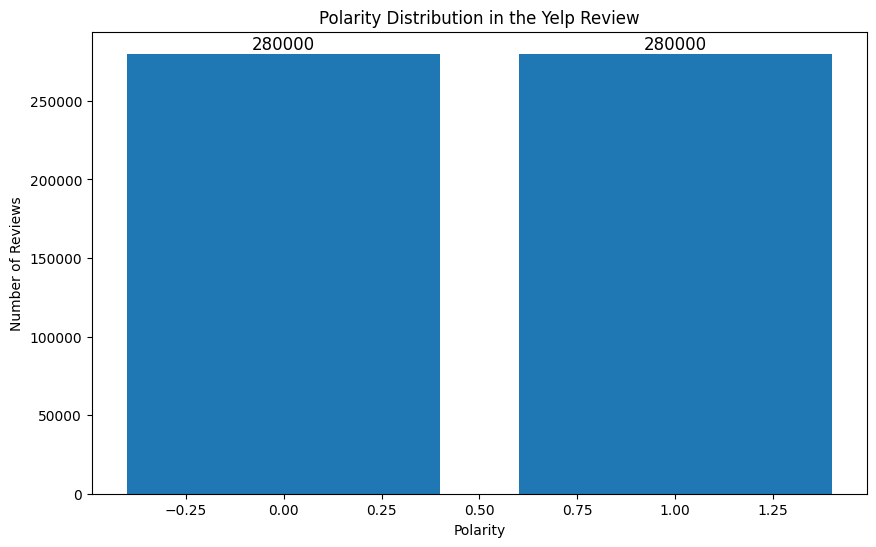

In [19]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(yelp_df, 'Yelp Review')

In [20]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(yelp_df, 'Review')  

   Token    Count
0      .  3977796
1    the  3169242
2      ,  2717635
3    and  2356227
4      I  2115246
5     to  1870691
6      a  1837871
7    was  1379177
8     of  1101404
9     it   928536
10    is   844433
11   for   837534
12    in   823774
13     !   790284
14  that   715968
15    my   566643
16  with   560569
17   you   549420
18   n't   539017
19   but   518953
20    on   512119
21   The   509584
22  this   475514
23  have   471896
24  they   458200


# 4. Sample and Save Data Sets

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# sample 20% of the data sets to shorten the future processing time
amazon_sample_df, _ = train_test_split(
    amazon_balanced_df, 
    test_size=0.8,
    stratify=amazon_balanced_df['Polarity'],  
    random_state=42
)

sentiment140_sample_df, _ = train_test_split(
    sentiment140_df, 
    test_size=0.8,
    stratify=sentiment140_df['Polarity'],  
    random_state=42
)

yelp_sample_df, _ = train_test_split(
    yelp_df, 
    test_size=0.8,
    stratify=yelp_df['Polarity'],  
    random_state=42
)

In [23]:
DataUtils.count_reviews_by_polarity(amazon_sample_df)

Number of reviews with Polarity=1: 70549
Number of reviews with Polarity=0: 70549


In [24]:
DataUtils.count_reviews_by_polarity(sentiment140_sample_df)

Number of reviews with Polarity=1: 160000
Number of reviews with Polarity=0: 160000


In [25]:
DataUtils.count_reviews_by_polarity(yelp_sample_df)

Number of reviews with Polarity=1: 56000
Number of reviews with Polarity=0: 56000


In [26]:
dfs = [amazon_sample_df, sentiment140_sample_df, yelp_sample_df]
dataset_names = ['Amazon', 'Sentiment140', 'Yelp']

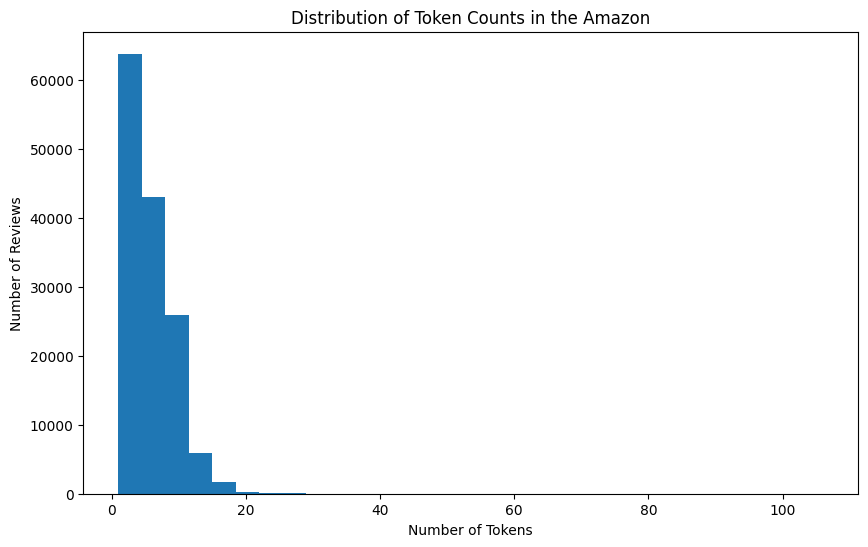

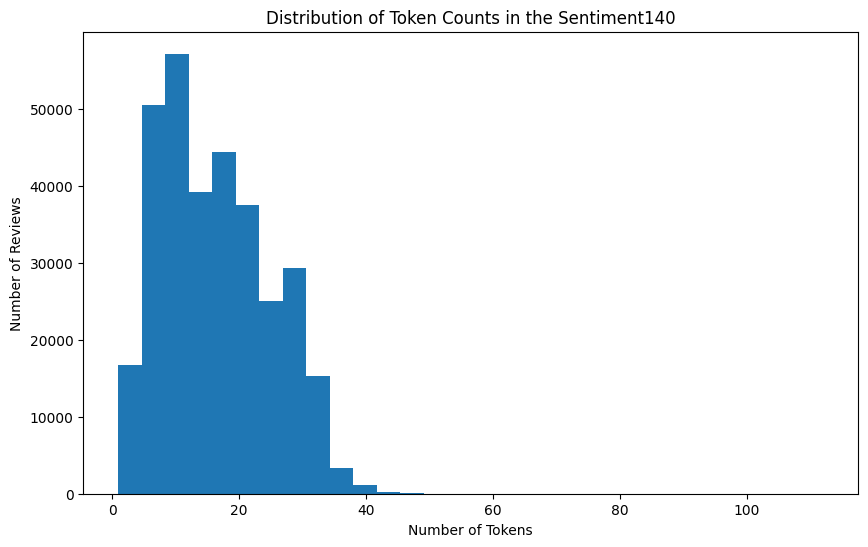

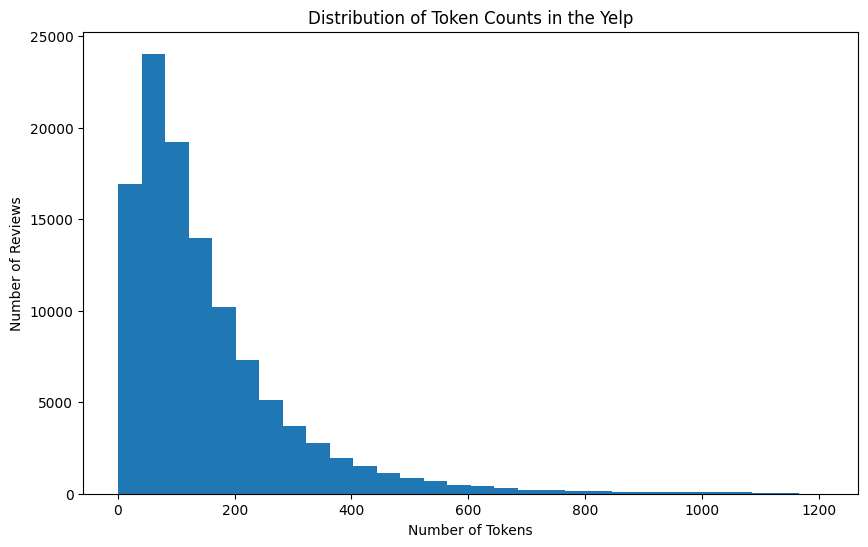

In [27]:
for df, name in zip(dfs, dataset_names):
    DataUtils.plot_token_distribution(df, name)

In [28]:
# path to the folder where files will be saved
output_dir = "../data/preprocessed/"

In [29]:
# save preprocessed Amazon set
amazon_sample_df.to_csv(os.path.join(output_dir, "amazon.csv"), index=False, encoding='utf-8')

# save preprocessed Sentiment140 set
sentiment140_sample_df.to_csv(os.path.join(output_dir, "sentiment140.csv"), index=False, encoding='utf-8')

# save preprocessed Yelp set
yelp_sample_df.to_csv(os.path.join(output_dir, "yelp.csv"), index=False, encoding='utf-8')

In [30]:
# split and save Amazon test set
train_amazon, test_amazon = train_test_split(
    amazon_sample_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_sample_df['Polarity']
)
test_amazon.to_csv(os.path.join(output_dir, "amazon_test.csv"), index=False, encoding='utf-8')

# split and save the Sentiment140 test set
train_sentiment140, test_sentiment140 = train_test_split(
    sentiment140_sample_df, 
    test_size=0.15, 
    random_state=42,
    stratify=sentiment140_sample_df['Polarity']
)
test_sentiment140.to_csv(os.path.join(output_dir, "sentiment140_test.csv"), index=False, encoding='utf-8')

# split and save the Yelp test set
train_yelp, test_yelp = train_test_split(
    yelp_sample_df, 
    test_size=0.15, 
    random_state=42,
    stratify=yelp_sample_df['Polarity']
)
test_yelp.to_csv(os.path.join(output_dir, "yelp_test.csv"), index=False, encoding='utf-8')

print("Test sets have been saved in the folder:", os.path.abspath(output_dir))

Test sets have been saved in the folder: d:\projects\sentiment-analysis\data\preprocessed
